![gym](gym.png)


You are a product manager for a fitness studio and are interested in understanding the current demand for digital fitness classes. You plan to conduct a market analysis in Python to gauge demand and identify potential areas for growth of digital products and services.

### The Data

You are provided with a number of CSV files in the "Files/data" folder, which offer international and national-level data on Google Trends keyword searches related to fitness and related products. 

### workout.csv

| Column     | Description              |
|------------|--------------------------|
| `'month'` | Month when the data was measured. |
| `'workout_worldwide'` | Index representing the popularity of the keyword 'workout', on a scale of 0 to 100. |

### three_keywords.csv

| Column     | Description              |
|------------|--------------------------|
| `'month'` | Month when the data was measured. |
| `'home_workout_worldwide'` | Index representing the popularity of the keyword 'home workout', on a scale of 0 to 100. |
| `'gym_workout_worldwide'` | Index representing the popularity of the keyword 'gym workout', on a scale of 0 to 100. |
| `'home_gym_worldwide'` | Index representing the popularity of the keyword 'home gym', on a scale of 0 to 100. |

### workout_geo.csv

| Column     | Description              |
|------------|--------------------------|
| `'country'` | Country where the data was measured. |
| `'workout_2018_2023'` | Index representing the popularity of the keyword 'workout' during the 5 year period. |

### three_keywords_geo.csv

| Column     | Description              |
|------------|--------------------------|
| `'country'` | Country where the data was measured. |
| `'home_workout_2018_2023'` | Index representing the popularity of the keyword 'home workout' during the 5 year period. |
| `'gym_workout_2018_2023'` | Index representing the popularity of the keyword 'gym workout' during the 5 year period.  |
| `'home_gym_2018_2023'` | Index representing the popularity of the keyword 'home gym' during the 5 year period. |

In [57]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
# Start coding here
workout = pd.read_csv("data/workout.csv")
three = pd.read_csv("data/three_keywords.csv")
workout_geo = pd.read_csv("data/workout_geo.csv")
three_keywords_geo = pd.read_csv("data/three_keywords_geo.csv")


In [59]:
print(workout.head())
print(workout.info())

     month  workout_worldwide
0  2018-03                 59
1  2018-04                 61
2  2018-05                 57
3  2018-06                 56
4  2018-07                 51
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   month              61 non-null     object
 1   workout_worldwide  61 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [60]:
workout["month"] = pd.to_datetime(workout['month'])
workout["year"] = workout['month'].dt.year
yearly = workout.groupby("year")["workout_worldwide"].mean()
print(yearly)
year_str = "2020"
print(year_str)

year
2018    53.600000
2019    53.833333
2020    64.416667
2021    57.083333
2022    53.833333
2023    58.000000
Name: workout_worldwide, dtype: float64
2020


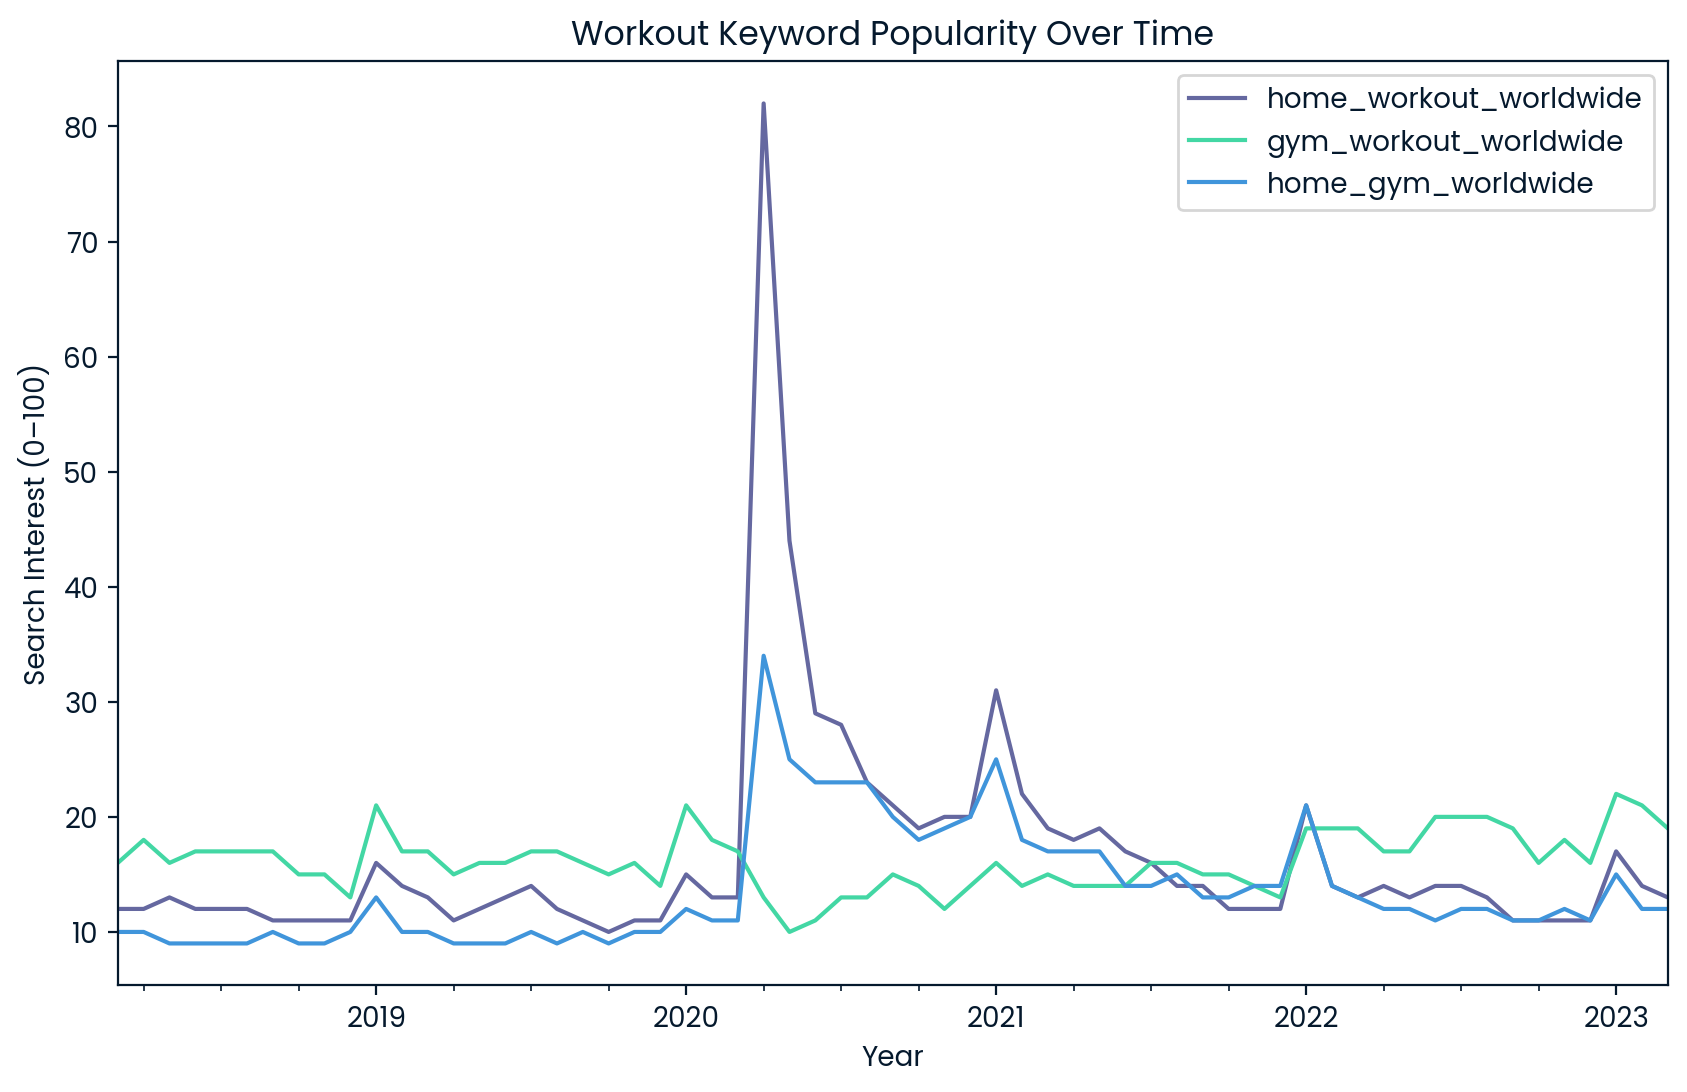

In [61]:
three['month'] = pd.to_datetime(three['month'])
three.set_index('month', inplace=True)
three.plot(figsize=(10,6))
plt.title("Workout Keyword Popularity Over Time")
plt.ylabel("Search Interest (0–100)")
plt.xlabel("Year")
plt.show()

In [62]:
peak_covid = "home_workout_worldwide"
current = "gym_workout_worldwide"

In [63]:
geo_filtered = workout_geo[workout_geo['country'].isin(
    ['United States', 'Australia', 'Japan']
)]
top_country = geo_filtered.loc[
    geo_filtered['workout_2018_2023'].idxmax(),
    'country'
]

In [64]:
# Fix: Check the actual column names and use the correct one
print(three_keywords_geo.columns)  # Debug: See available columns

# Let's assume the actual column name is 'Country' (capitalized), which is a common cause
home_geo = three_keywords_geo[three_keywords_geo['Country'].isin(
    ['Philippines', 'Malaysia']
)]
home_workout_geo = home_geo.loc[
    home_geo['home_workout_2018_2023'].idxmax(),
    'Country'
]
print(home_workout_geo)

Index(['Country', 'home_workout_2018_2023', 'gym_workout_2018_2023',
       'home_gym_2018_2023'],
      dtype='object')
Philippines
